In [1]:
import slicersim

In [2]:
import slicersim

config = slicersim.iotools.get_config(scene='supernova.toml')
sim = slicersim.Simulation.from_config(config)

In [3]:
sim

--------------------- Scene ----------------------
{'target': {'beta': 3.15,
            'alpha': -0.14,
            'c': 0,
            'x1': 0,
            'cosmo': FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897),
            'source': 'salt2-extended',
            'MBmax': -19.3,
            'name': 'SN Ia',
            'redshift': 1.5,
            'phase': 0,
            'position': [1, 0.5]},
 'background': {'model': 'Aldering01.BB5800', 'scale': 2.0, 'name': 'zodi'},
 'host': None}
------------------ Spectrograph ------------------
Spectrograph 'NACRE (baseline)':
  Spectral range: 4_000-17_000 Å, 456 px
  Spectral dispersion: 'dispersion_offner.ecsv' ×1.3 (R0~141)
  Spectral PSF: chromatic σ=0.90 px at 1 µm, x-disp. σ=0.30 px
  Resolving power (2-px + σ): R~127 (λ-average), min=95 at 12_802 Å
  MLA: 15×16 spx of 40 mas
  Spatial PSF: chromatic σ=30 mas at 1 µm, guiding σ=10 mas
  Total throughp

# Obtain a spectrum

In [4]:
lbda, flux, variance = sim.get_spectrum(incl_error=True)

In [16]:
sim.scene.update(target__redshift=1.2)
lbda, flux_1, variance_1 = sim.get_spectrum(incl_error=True)

sim.scene.update(target__redshift=0.7)
lbda, flux_2, variance_2 = sim.get_spectrum(incl_error=True)

In [17]:
%matplotlib widget

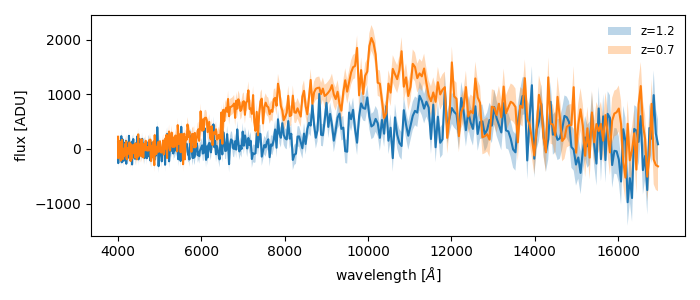

In [18]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=[7,3])

ax.plot(lbda, flux_1)
ax.fill_between(lbda, 
                flux_1-np.sqrt(variance_1),
                flux_1+np.sqrt(variance_1), alpha=0.3,
               label="z=1.2")

ax.plot(lbda, flux_2)
ax.fill_between(lbda, 
                flux_2-np.sqrt(variance_2),
                flux_2+np.sqrt(variance_2), alpha=0.3,
               label="z=0.7")
ax.legend(frameon=False, fontsize="small")
ax.set(xlabel=r"wavelength [$\AA$]", ylabel="flux [ADU]")
fig.tight_layout()
fig.savefig("/Users/rigault/libraries/from_perl/slicersim/docs/gallery/spectra_examples.png", dpi=100)

# Get the variance origin

In [10]:
sim.estimate_variance_contribution([8000, 12000], frame="obs")

{'snr': 24.932873980650992,
 'exptime': 724.48,
 'inttime': 679.2,
 'obstime': 724.48,
 'signal': 1105.15356350384,
 'variance': 1964.719578097868,
 'frac_dark': 0.1688435570706089,
 'frac_ron': 0.08740416618631135,
 'frac_background': 0.049027692447717056,
 'frac_target': 0.7676399261325038,
 'frac_thermal': 3.249848652982881e-08}

In [11]:
sim.update(detector__ron=200)

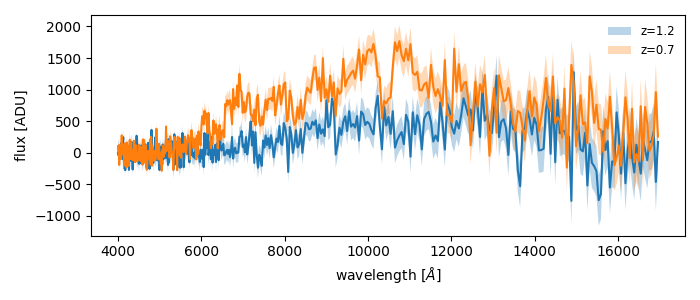

In [12]:
sim.update(target__redshift=1.2)
lbda, flux_1, variance_1 = sim.get_spectrum(incl_error=True)

sim.update(target__redshift=0.7)
lbda, flux_2, variance_2 = sim.get_spectrum(incl_error=True)


import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=[7,3])

ax.plot(lbda, flux_1)
ax.fill_between(lbda, 
                flux_1-np.sqrt(variance_1),
                flux_1+np.sqrt(variance_1), alpha=0.3,
               label="z=1.2")

ax.plot(lbda, flux_2)
ax.fill_between(lbda, 
                flux_2-np.sqrt(variance_2),
                flux_2+np.sqrt(variance_2), alpha=0.3,
               label="z=0.7")
ax.legend(frameon=False, fontsize="small")
ax.set(xlabel=r"wavelength [$\AA$]", ylabel="flux [ADU]")
fig.tight_layout()
#fig.savefig("/Users/rigault/libraries/from_perl/slicersim/docs/gallery/spectra_examples.png", dpi=100)

In [13]:
sim.get_band_snr([4000, 6000], frame="rest")

4.928157048660491

In [15]:
sim.get_band_flux([4000, 6000], frame="rest")

(949.016705916453, 37083.322365292384)